In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Dropout, Bidirectional, LSTM, Flatten
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.layers import Layer


In [ ]:
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")
        super(Attention, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
train_df = pd.read_csv("/content/drive/MyDrive/train_balanced (2).csv")
test_df = pd.read_csv("/content/drive/MyDrive/test_balanced (2).csv")

# Remove unwanted columns
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]
test_df  = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]

label_col = "label"

X_train = train_df.drop(label_col, axis=1)
y_train = train_df[label_col]

X_test  = test_df.drop(label_col, axis=1)
y_test  = test_df[label_col]

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Scale (removed as per user request)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled  = scaler.transform(X_test)

# Reshape for sequence model using unscaled data
n_features = X_train.shape[1]
X_train_seq = X_train.values.reshape(X_train.shape[0], n_features, 1)
X_test_seq  = X_test.values.reshape(X_test.shape[0], n_features, 1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model = Sequential([

    # 1) Feature extraction
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(n_features, 1)),


    # 2) Temporal modeling
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    # 3) Attention mechanism
    Attention(),

    # 4) Dense classifier
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(len(le.classes_), activation='softmax')
])

optimizer = AdamW(learning_rate=0.001, weight_decay=1e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 256)            │           266 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,488 (1.17 MB)

 Trainable params: 305,488 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_seq, y_train_enc,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 146s 11ms/step - accuracy: 0.7432 - loss: 0.6275 - val_accuracy: 0.8294 - val_loss: 0.4427
Epoch 2/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 137s 10ms/step - accuracy: 0.8408 - loss: 0.4273 - val_accuracy: 0.8697 - val_loss: 0.3505
Epoch 3/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 137s 10ms/step - accuracy: 0.8678 - loss: 0.3646 - val_accuracy: 0.8864 - val_loss: 0.3114
Epoch 4/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 143s 11ms/step - accuracy: 0.8817 - loss: 0.3309 - val_accuracy: 0.8923 - val_loss: 0.2983
Epoch 5/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 137s 10ms/step - accuracy: 0.8916 - loss: 0.3068 - val_accuracy: 0.9004 - val_loss: 0.2770
Epoch 6/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 142s 10ms/step - accuracy: 0.8987 - loss: 0.2879 - val_accuracy: 0.9048 - val_loss: 0.2661
Epoch 7/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 139s 11ms/step - accuracy: 0.9036 - loss: 0.2743 - val_accuracy: 0.9080 - val_loss: 0.2599
Epoch 8/80
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 138s 11ms/s

In [ ]:
history2 = model.fit(
    X_train_seq, y_train_enc,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 145s 11ms/step - accuracy: 0.9489 - loss: 0.1472 - val_accuracy: 0.9250 - val_loss: 0.2260
Epoch 2/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 201s 11ms/step - accuracy: 0.9497 - loss: 0.1450 - val_accuracy: 0.9256 - val_loss: 0.2238
Epoch 3/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 143s 11ms/step - accuracy: 0.9491 - loss: 0.1471 - val_accuracy: 0.9252 - val_loss: 0.2261
Epoch 4/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 143s 11ms/step - accuracy: 0.9492 - loss: 0.1463 - val_accuracy: 0.9264 - val_loss: 0.2223
Epoch 5/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9489 - loss: 0.1464 - val_accuracy: 0.9263 - val_loss: 0.2257
Epoch 6/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 150s 11ms/step - accuracy: 0.9496 - loss: 0.1464 - val_accuracy: 0.9253 - val_loss: 0.2268
Epoch 7/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 143s 11ms/step - accuracy: 0.9497 - loss: 0.1444 - val_accuracy: 0.9258 - val_loss: 0.2255
Epoch 8/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 143s 11ms/s

In [8]:
history2 = model.fit(
    X_train_seq, y_train_enc,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9500 - loss: 0.1451 - val_accuracy: 0.9264 - val_loss: 0.2289
Epoch 2/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9500 - loss: 0.1435 - val_accuracy: 0.9249 - val_loss: 0.2329
Epoch 3/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9500 - loss: 0.1438 - val_accuracy: 0.9272 - val_loss: 0.2273
Epoch 4/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9499 - loss: 0.1442 - val_accuracy: 0.9253 - val_loss: 0.2277
Epoch 5/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 151s 11ms/step - accuracy: 0.9503 - loss: 0.1441 - val_accuracy: 0.9259 - val_loss: 0.2304
Epoch 6/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9506 - loss: 0.1426 - val_accuracy: 0.9264 - val_loss: 0.2256
Epoch 7/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/step - accuracy: 0.9503 - loss: 0.1432 - val_accuracy: 0.9241 - val_loss: 0.2294
Epoch 8/10
13108/13108 ━━━━━━━━━━━━━━━━━━━━ 144s 11ms/s

In [9]:
test_loss, test_acc = model.evaluate(X_test_seq, y_test_enc, verbose=0)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


Test Loss: 0.2292608916759491
Test Accuracy: 0.9261119365692139


In [10]:
y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)


8831/8831 ━━━━━━━━━━━━━━━━━━━━ 23s 3ms/step


In [11]:
print(classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
))


              precision    recall  f1-score   support

  downstairs       0.77      0.77      0.77     26372
     jogging       0.89      0.88      0.89     26847
     sitting       1.00      1.00      1.00     67756
    standing       1.00      0.99      0.99     61286
    upstairs       0.82      0.81      0.82     31457
     walking       0.91      0.93      0.92     68858

    accuracy                           0.93    282576
   macro avg       0.90      0.90      0.90    282576
weighted avg       0.93      0.93      0.93    282576



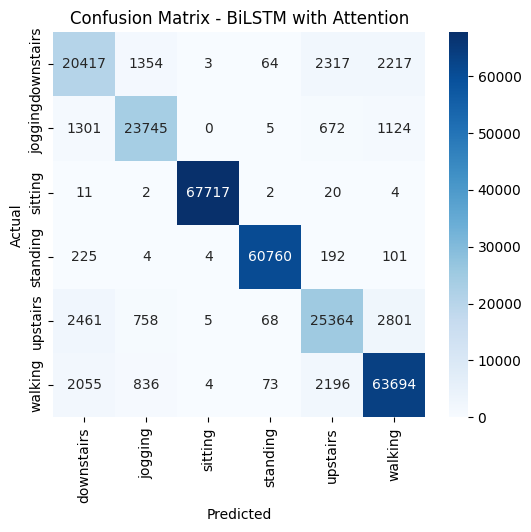

In [12]:
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BiLSTM with Attention")
plt.show()


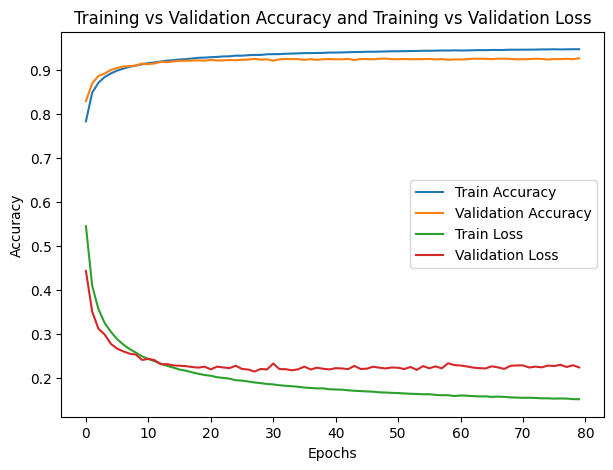

In [14]:
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy and Training vs Validation Loss')
plt.show()


In [15]:
model.save("/content/drive/MyDrive/bilstm_attention_fyp_model.h5")


In [16]:
import tensorflow as tf

# Make sure the Attention class is defined or imported before loading the model
# Assuming the Attention class is still defined in cell dT0HgwM-1Zrv

model = tf.keras.models.load_model("/content/drive/MyDrive/bilstm_attention_fyp_model.h5", custom_objects={'Attention': Attention})

# Explicitly build the model after loading to ensure input shapes are set
# The input shape for the model is (n_features, 1) as defined in Conv1D
model.build(input_shape=(None, n_features, 1))

In [17]:
y_pred_probabilities = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probabilities, axis=1)
acc = accuracy_score(y_test_enc, y_pred)
print("Accuracy:", acc)

8831/8831 ━━━━━━━━━━━━━━━━━━━━ 25s 3ms/step
Accuracy: 0.926111913255195


In [19]:
import joblib

# joblib.dump(scaler, "scaler.pkl") # Removed as scaler was not used/defined
joblib.dump(le, "label_encoder.pkl")
model.save("bilstm_attention.h5")

In [21]:
from google.colab import files
files.download("bilstm_attention.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
model.save("/content/drive/MyDrive/bilstm_attention_model.h5")
